In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats 

df = pd.read_csv("cookie_cats.csv")

print(" data set sum :")
print(df.info())
print("\n---- group distribitions----")
print(df["version"].value_counts()) # are gate_30 and gate_40 counts balanced?
print("sum of rows for userid:", len(df["userid"]))
print("sum of unique rows for userid:", df["userid"].nunique())

 data set sum :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB
None

---- group distribitions----
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
sum of rows for userid: 90189
sum of unique rows for userid: 90189


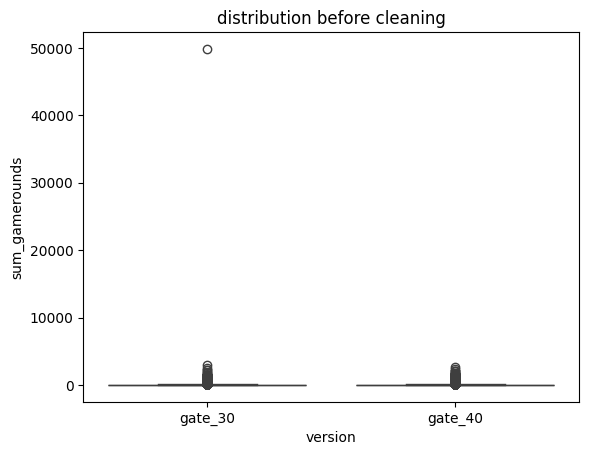

In [8]:
#reviewing outliers

sns.boxplot(x="version", y="sum_gamerounds", data=df)
plt.title("distribution before cleaning")
plt.show()

new max gameround after cleaning: 2961


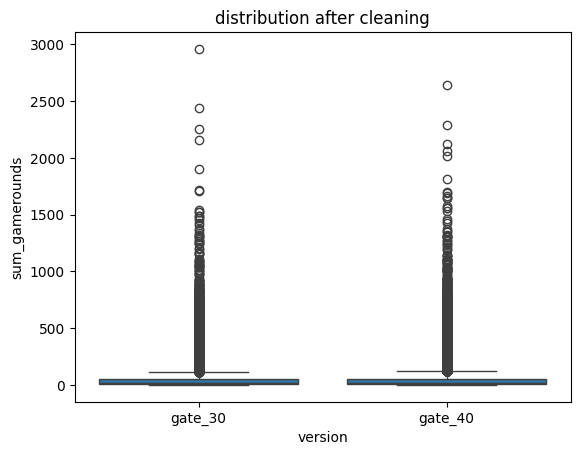

In [9]:
max_gamerounds = df["sum_gamerounds"].max()
df = df[df["sum_gamerounds"]< max_gamerounds]

print("new max gameround after cleaning:", df["sum_gamerounds"].max())
sns.boxplot(x="version", y="sum_gamerounds", data=df)
plt.title("distribution after cleaning")
plt.show()

In [11]:
#prepare the groups

g_A = df[df["version"]=="gate_30"]["sum_gamerounds"]
g_B = df[df["version"]=="gate_40"]["sum_gamerounds"]

print("Normal dist. test:")
ntest_A = stats.shapiro(g_A.sample(1000, random_state=42))
ntest_B = stats.shapiro(g_B.sample(1000, random_state=42))

print(f"Gate 30 (A) Normal d. p-value: {ntest_A.pvalue:.5f}")
print(f"Gate 40 (B) Normal d. p-value: {ntest_B.pvalue:.5f}")
print("---> if p<0.05 group data isn't distributed normally.")

print("variance comparison test:")
levene_test= stats.levene(g_A,g_B)
print(f"Varience comparison p-value: {levene_test.pvalue:.5f}")
print("----> if p<0.05 varience of groups are not equal.")


Normal dist. test:
Gate 30 (A) Normal d. p-value: 0.00000
Gate 40 (B) Normal d. p-value: 0.00000
---> if p<0.05 group data isn't distributed normally.
variance comparison test:
Varience comparison p-value: 0.78405
----> if p<0.05 varience of groups are not equal.


/Users/berfinkilinc/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/berfinkilinc/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


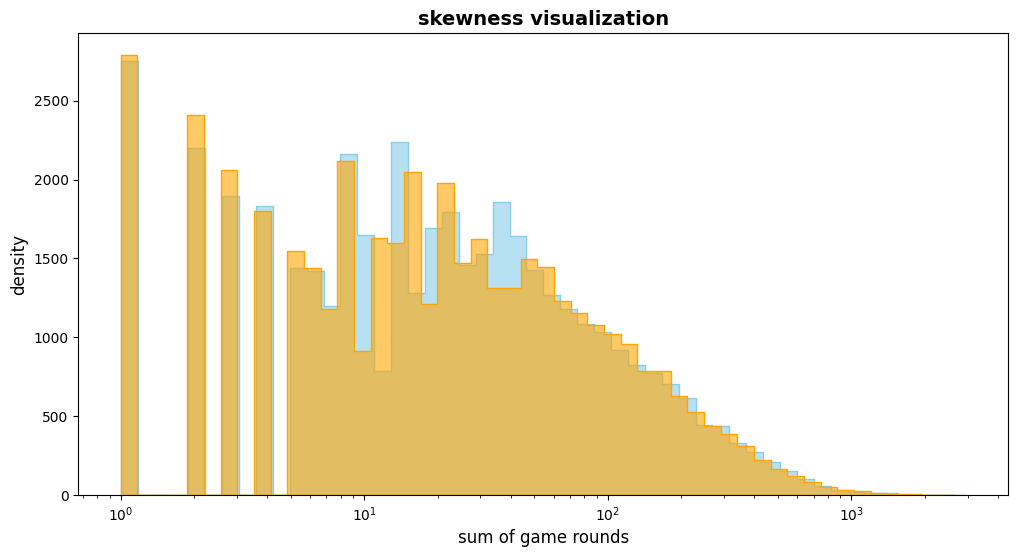

In [15]:
plt.figure(figsize=(12,6))

sns.histplot(g_A, color= "skyblue", label= "gate 30 (group A)", kde=True, bins=50, alpha=0.6,log_scale=True, element="step")
sns.histplot(g_B, color= "orange", label="gate 40 (group B)", kde=True, bins=50, alpha= 0.6, log_scale=True, element="step")

plt.title("skewness visualization", fontsize=14, fontweight= "bold")
plt.xlabel("sum of game rounds",fontsize=12)
plt.ylabel("density", fontsize= 12)

plt.show()

In [17]:
#since its not normally distributed we use the mannwhitneyu test.

u_stat, p_val = stats.mannwhitneyu(g_A, g_B, alternative="two-sided")

print("mannwhitney u test results:")
print(f"u stats: {u_stat}")
print(f"p-value :{p_val:.5f}")

if p_val < 0.05:
    print("\n result: since p<0.05 H0 is rejected.")
    print("there is a statistically significant difference between the gate 30 and gate 40 groups.")

else:
    print("\n result: since p>=0.05 H0 cannot be rejected.")
    print("there is no statistically significant difference between the gate 30 and gate 40 groups. ")

mannwhitney u test results:
u stats: 1024285761.5
p-value :0.05089

 result: since p>=0.05 H0 cannot be rejected.
there is no statistically significant difference between the gate 30 and gate 40 groups. 


> **Note (Marginal Significance):** Although $p \approx 0.051$ is technically above our $\alpha = 0.05$ threshold (meaning no statistically significant difference), it is extremely borderline. it is highly recommended to run the test slightly longer to gather more data and confirm this result before making a final decision.

In [19]:
#we couldnt obtain a meaningful result from gamerounds yet, we shall keep exploring

r1_sum= df.groupby("version")["retention_1"].mean()*100
print("1st day retention rates:")
print(r1_sum)

r7_sum= df.groupby("version")["retention_7"].mean()*100
print("7th day retention rates:")
print(r7_sum)

print("1st day retention analysis:")

crosstab_r1 = pd.crosstab(df["version"],df["retention_1"])
print(crosstab_r1)

chi2_r1, p_val_r1, dof_r1 , expected_r1 = stats.chi2_contingency(crosstab_r1)
print(f"\n1st day chi2 p-value: {p_val_r1:.5f}")

if p_val_r1 < 0.05:
    print("1st day retention difference is statistically significant between the groups.")

else:
    print("1st day retention is not statistically significant between the groups.")


crosstab_r7= pd.crosstab(df["version"],df["retention_7"])
print(crosstab_r7)
chi2_r7, p_val_r7, dof_r7, expected_r7= stats.chi2_contingency(crosstab_r7)
print(f"\n 7th day chi2 p-value: {p_val_r7:.5f}")

if p_val_r7 < 0.05:
    print("7th day retention difference is statistically significant between the groups of gate 30 and gate 40. ")
else:
    print("7th day retention is not statistically significant between the groups.")



1st day retention rates:
version
gate_30    44.819795
gate_40    44.228275
Name: retention_1, dtype: float64
7th day retention rates:
version
gate_30    19.018323
gate_40    18.200004
Name: retention_7, dtype: float64
1st day retention analysis:
retention_1  False  True 
version                  
gate_30      24665  20034
gate_40      25370  20119

1st day chi2 p-value: 0.07501
1st day retention is not statistically significant between the groups.
retention_7  False  True 
version                  
gate_30      36198   8501
gate_40      37210   8279

 7th day chi2 p-value: 0.00164
7th day retention difference is statistically significant between the groups of gate 30 and gate 40. 


##  Conclusion & Recommendation

* **1st Day Retention:** There is **no statistically significant difference** between the two groups ($p \approx 0.075$, which is above $\alpha = 0.05$). Changing the gate level did not impact players' immediate reaction to the game.
* **7th Day Retention:** There is a **highly statistically significant difference** between the groups ($p \approx 0.0016$). Setting the gate at level 30 yields a higher 7th-day retention rate ($19.02\%$) compared to level 40 ($18.20\%$).

### Decision:
Based on the A/B testing results, **the company should keep the gate at level 30**. 
While moving the gate to level 40 allows longer uninterrupted gameplay, it leads to a significant drop in long-term player retention.